In [2]:
# Cell 1: Setup & Configuration
import os
import re
import io
import requests
import zipfile
import pandas as pd
import numpy as np
import logging
from datetime import datetime, timedelta
from pandas_datareader import data as pdr

# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# --- PIPELINE CONFIGURATION ---

# 1. Date Range for the Pipeline
# User Requirement: GDELT from 31/12/2019 (to capture news affecting 1/1/2020 market open)
START_DATE = '2019-12-31' 
END_DATE   = datetime.now().strftime('%Y-%m-%d') # Dynamic end date (today)

# 2. Target Stocks & Strict Aliases
# Logic: We ONLY keep news where the Title/URL explicitly mentions these keywords.
STOCK_CONFIG = {
    # 1. THE HYPE STOCK: NVIDIA
    # High Volatility, High Sentiment Sensitivity
    'NVDA': {
        'aliases': ['nvidia', 'jensen huang', 'geforce', 'rtx', 'nvda'],
        'blacklist': [] # "Nvidia" is unique, very little noise
    },
    
    # 2. THE STABLE STOCK: MICROSOFT
    # Lower Volatility, "Control Group"
    'MSFT': {
        'aliases': ['microsoft', 'satya nadella', 'azure', 'msft'],
        'blacklist': [] # "Microsoft" is unique
    }
}

# 3. Layer Paths (Simulating S3/MinIO Buckets)
BASE_DIR = './data_pipeline'
BRONZE_DIR = f'{BASE_DIR}/bronze'   # Raw Data
SILVER_DIR = f'{BASE_DIR}/silver'   # Cleaned & Filtered
GOLD_DIR   = f'{BASE_DIR}/gold'     # Aggregated & ML Ready

for d in [BRONZE_DIR, SILVER_DIR, GOLD_DIR]:
    os.makedirs(d, exist_ok=True)
    
print("✓ Configuration Loaded & Directories Created")
print(f"  - Pipeline Window: {START_DATE} to {END_DATE}")

✓ Configuration Loaded & Directories Created
  - Pipeline Window: 2019-12-31 to 2025-12-23


In [2]:
# Cell 2: BRONZE LAYER - Ingestion (BigQuery)
# FIXED: Regex logic for URLs and Date Configuration

from google.cloud import bigquery
import os
import re
import logging
from datetime import datetime, timedelta
from pandas_datareader import data as pdr

# --- DATE CONFIGURATION ---
# Use the global variables from Cell 1 if they exist, otherwise default to last 7 days
if 'START_DATE' not in globals():
    TODAY = datetime.now()
    START_DATE = (TODAY - timedelta(days=7)).strftime('%Y-%m-%d')
    END_DATE = (TODAY - timedelta(days=1)).strftime('%Y-%m-%d')

logger.info(f"Querying Real-World GDELT Data: {START_DATE} to {END_DATE}")

def generate_bq_filter(config):
    """
    Constructs a SQL WHERE clause.
    FIX: Simplified regex to ensure data capture from URLs.
    """
    stock_conditions = []
    
    for ticker, rules in config.items():
        # regex escape ensures special chars in alias don't break SQL
        # We removed \\b (word boundary) because it breaks URL matching (e.g. 'nvidia-stock')
        aliases = [re.escape(a) for a in rules['aliases']]
        alias_str = "|".join(aliases)
        
        condition = f"REGEXP_CONTAINS(DocumentIdentifier, r'(?i){alias_str}')"
        
        if rules['blacklist']:
            blacklist = [re.escape(b) for b in rules['blacklist']]
            blk_str = "|".join(blacklist)
            condition += f" AND NOT REGEXP_CONTAINS(DocumentIdentifier, r'(?i){blk_str}')"
            
        stock_conditions.append(f"({condition})")
    
    return " OR ".join(stock_conditions)

def download_gdelt_bronze_bq(start, end, output_dir, config):
    client = bigquery.Client()
    filter_logic = generate_bq_filter(config)
    
    # We select specific columns to minimize data transfer costs
    query = f"""
        SELECT 
            DATE, 
            DocumentIdentifier as source_url, 
            Themes as themes, 
            Organizations as organizations, 
            V2Tone as tone,
            Extras as extras,
            TranslationInfo as translation_info
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE _PARTITIONDATE BETWEEN DATE('{start}') AND DATE('{end}')
          AND (TranslationInfo IS NULL OR LENGTH(TranslationInfo) = 0) -- English Only
          AND ({filter_logic})
    """
    
    logger.info("Running BigQuery Job (This may take time for large date ranges)...")
    
    try:
        query_job = client.query(query)
        df = query_job.to_dataframe()
        
        if not df.empty:
            filename = f"gdelt_bronze_bq_{start}_{end}.csv"
            save_path = os.path.join(output_dir, filename)
            df.to_csv(save_path, index=False)
            logger.info(f"✓ Downloaded {len(df)} rows to {save_path}")
            return save_path
        else:
            logger.warning(f"BigQuery returned 0 rows for {start} to {end}.")
            return None
            
    except Exception as e:
        logger.error(f"BigQuery Failed: {e}")
        return None

def download_stooq_bronze(tickers, output_dir):
    for ticker in tickers:
        logger.info(f"Downloading Bronze Stooq: {ticker}")
        try:
            # Fetch data explicitly from 2020-01-01 as requested
            # Stooq usually provides OHLCV data aligned with US Market Close
            df = pdr.DataReader(ticker, 'stooq', start=datetime(2020, 1, 1), end=datetime.now())
            if not df.empty:
                save_path = f"{output_dir}/stooq_{ticker}.csv"
                df.to_csv(save_path)
                logger.info(f"✓ Saved {len(df)} rows for {ticker}")
        except Exception as e:
            logger.error(f"Stooq failed for {ticker}: {e}")

# --- EXECUTION ---
print("--- Starting Bronze Ingestion (BigQuery) ---")
bq_file = download_gdelt_bronze_bq(START_DATE, END_DATE, BRONZE_DIR, STOCK_CONFIG)
download_stooq_bronze(STOCK_CONFIG.keys(), BRONZE_DIR)
print("✓ Bronze Layer Complete")

2025-12-23 11:01:40,093 - INFO - Querying Real-World GDELT Data: 2019-12-31 to 2025-12-23
/Users/mac/Git/DQOPs/.venv/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


--- Starting Bronze Ingestion (BigQuery) ---


/Users/mac/Git/DQOPs/.venv/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
2025-12-23 11:01:41,509 - INFO - Running BigQuery Job (This may take time for large date ranges)...
/Users/mac/Git/DQOPs/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2025-12-23 11:18:32,626 - INFO - ✓ Downloaded 491172 rows to ./data_pipeline/bronze/gdelt_bronze_bq_2019-12-31_2025-12-23.csv
2025-12-23 11:18:32,717 - INFO - Downloading Bronze Stooq: NVDA
2025-12-23 11:18:35,117 - INFO - ✓ Saved 1502 rows for NVDA
2025-12

✓ Bronze Layer Complete


In [8]:
# Cell 3: SILVER LAYER - Transformation (Strict Title & Timezone Alignment)
# FIXED: Syntax error in print statement and robust timezone handling.

import pytz

def extract_title_from_xml(extras_str):
    if not isinstance(extras_str, str): return None
    try:
        match = re.search(r'<PAGE_TITLE>(.*?)</PAGE_TITLE>', extras_str)
        if match:
            return match.group(1).strip()
    except:
        pass
    return None

def extract_title_from_url_slug(url):
    if not isinstance(url, str): return ""
    try:
        slug = re.search(r'([^/]+)(?:\.html|\?|$)', url.strip('/'))
        if slug:
            text = slug.group(1)
            text = re.sub(r'\d+', '', text)
            text = text.replace('-', ' ').replace('_', ' ').replace('+', ' ')
            return text.strip().title()
    except:
        pass
    return ""

def assign_trading_date(row):
    """
    Giả lập chạy model lúc 09:00 sáng.
    - Tin tức trước 09:00 sáng ngày T -> Thuộc về ngày T (Dùng để dự báo T).
    - Tin tức sau 09:00 sáng ngày T -> Thuộc về ngày T+1 (Quá trễ để dùng cho ngày T).
    """
    dt_est = row['timestamp_et']
    if pd.isnull(dt_est): return None
    
    # Cắt off lúc 9:00 sáng
    if dt_est.hour < 9:
        # Ví dụ: 8h sáng ngày 15 -> Thuộc trading date 15
        return dt_est.normalize()
    else:
        # Ví dụ: 10h sáng ngày 15 -> Thuộc trading date 16 (Dành cho dự báo hôm sau)
        # Ví dụ: 17h chiều ngày 15 -> Thuộc trading date 16
        return (dt_est + timedelta(days=1)).normalize()

def process_gdelt_silver(bronze_dir, silver_dir, config):
    all_files = [f for f in os.listdir(bronze_dir) if f.startswith('gdelt_bronze_bq_')]
    if not all_files:
        logger.warning("No BigQuery dump found in Bronze.")
        return pd.DataFrame()
    
    silver_rows = []
    
    for f in all_files:
        path = os.path.join(bronze_dir, f)
        try:
            # low_memory=False helps with mixed types in GDELT Extras column
            df = pd.read_csv(path, low_memory=False)
        except Exception as e:
            logger.warning(f"Could not read {f}: {e}")
            continue

        if df.empty: continue

        # --- STEP 1: RESOLVE TITLES ---
        df['xml_title'] = df['extras'].apply(extract_title_from_xml)
        df['url_title'] = df['source_url'].apply(extract_title_from_url_slug)
        df['final_title'] = df['xml_title'].fillna(df['url_title'])
        # Filter out garbage titles that are too short
        df = df[df['final_title'].str.len() > 10]

        # --- STEP 2: CRITICAL TIMEZONE FIX (NASDAQ ALIGNMENT) ---
        # GDELT 'DATE' is int YYYYMMDDHHMMSS (UTC)
        df['timestamp_utc'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
        df = df.dropna(subset=['timestamp_utc'])
        
        # 1. Localize to UTC
        df['timestamp_utc'] = df['timestamp_utc'].dt.tz_localize('UTC')
        
        # 2. Convert to US/Eastern (NASDAQ Time)
        # This handles Daylight Savings automatically
        df['timestamp_et'] = df['timestamp_utc'].dt.tz_convert('US/Eastern')
        
        # 3. Assign Trading Date based on 16:00 Cut-off
        df['trading_date'] = df.apply(assign_trading_date, axis=1)
        df = df.dropna(subset=['trading_date'])

        # --- STEP 3: STRICT FILTERING ---
        for ticker, rules in config.items():
            aliases = rules['aliases']
            # Simplified Python regex for Silver filtering as well
            alias_pattern = '|'.join([re.escape(a) for a in aliases])
            
            mask_title = df['final_title'].str.contains(alias_pattern, case=False, na=False, regex=True)
            
            mask_noise = pd.Series([False] * len(df), index=df.index)
            if rules['blacklist']:
                blk_pattern = '|'.join([re.escape(b) for b in rules['blacklist']])
                noise_title = df['final_title'].str.contains(blk_pattern, case=False, na=False, regex=True)
                noise_url = df['source_url'].str.contains(blk_pattern, case=False, na=False, regex=True)
                mask_noise = noise_title | noise_url

            matches = df[mask_title & (~mask_noise)].copy()
            
            if not matches.empty:
                matches['ticker'] = ticker
                # We use 'trading_date' as the join key, not the raw calendar date
                matches['date'] = matches['trading_date'].dt.strftime('%Y-%m-%d')
                
                silver_rows.append(matches[['date', 'ticker', 'final_title', 'source_url', 'timestamp_et']].rename(columns={'final_title': 'extracted_title'}))
                
    if silver_rows:
        df_silver = pd.concat(silver_rows, ignore_index=True)
        # Deduplicate on trading date/ticker/title
        df_silver = df_silver.drop_duplicates(subset=['date', 'ticker', 'extracted_title'])
        
        out_path = f"{silver_dir}/news_silver.csv"
        df_silver.to_csv(out_path, index=False)
        print(f"Saved Silver News: {out_path} ({len(df_silver)} rows)")
        return df_silver
    else:
        print("No relevant news found in Bronze.")
        return pd.DataFrame()

def process_stooq_silver(bronze_dir, silver_dir):
    all_files = [f for f in os.listdir(bronze_dir) if f.startswith('stooq_')]
    silver_stocks = []
    
    for f in all_files:
        ticker = f.replace('stooq_', '').replace('.csv', '')
        try:
            df = pd.read_csv(os.path.join(bronze_dir, f))
        except Exception as e:
            logger.warning(f"Error reading stock file {f}: {e}")
            continue
        
        df.columns = [c.lower() for c in df.columns]
        if 'date' in df.columns:
            # Stooq dates are already Local Market Date (YYYY-MM-DD)
            df['date'] = pd.to_datetime(df['date'])
            df['ticker'] = ticker
            silver_stocks.append(df[['date', 'ticker', 'close', 'open', 'high', 'low', 'volume']])
            
    if silver_stocks:
        df_stocks = pd.concat(silver_stocks, ignore_index=True)
        out_path = f"{silver_dir}/stocks_silver.csv"
        df_stocks.to_csv(out_path, index=False)
        print(f"Saved Silver Stocks: {out_path}")

# --- EXECUTION ---
print("--- Starting Silver Transformation ---") 
df_news_silver = process_gdelt_silver(BRONZE_DIR, SILVER_DIR, STOCK_CONFIG)
process_stooq_silver(BRONZE_DIR, SILVER_DIR)
print("✓ Silver Layer Complete")

--- Starting Silver Transformation ---
Saved Silver News: ./data_pipeline/silver/news_silver.csv (301149 rows)
Saved Silver Stocks: ./data_pipeline/silver/stocks_silver.csv
✓ Silver Layer Complete


In [9]:
# Cell 4: NLP Processing
# Goal: Prepare data for model, simulate scoring, and get ready for Gold aggregation.

def generate_nlp_input(silver_dir):
    """Creates the file your NLP model needs to read."""
    path = f"{silver_dir}/news_silver.csv"
    if not os.path.exists(path): return pd.DataFrame()
    
    df = pd.read_csv(path)
    # The NLP model needs strict columns: date, entity, text
    nlp_input = df[['date', 'ticker', 'extracted_title']].rename(columns={'ticker': 'entity', 'extracted_title': 'title'})
    
    # Save input for external model
    nlp_input.to_csv(f"{silver_dir}/nlp_input_ready.csv", index=False)
    print(f"Generated NLP Input: {silver_dir}/nlp_input_ready.csv")
    return nlp_input

def simulate_nlp_output(silver_dir):
    """
    MOCKS the output of your T5/BERT model. 
    In production, you would run the model script here instead.
    """
    input_df = generate_nlp_input(silver_dir)
    if input_df.empty: return pd.DataFrame()
    
    # Mocking a Sentiment Score (-1 to 1)
    # We add random noise to test the pipeline
    scored_df = input_df.copy()
    scored_df['sentiment_score'] = np.random.uniform(-1, 1, size=len(scored_df))
    
    # Save as if the model just finished running
    scored_df.to_csv(f"{silver_dir}/nlp_output_scored.csv", index=False)
    print(f"Simulated NLP Output: {silver_dir}/nlp_output_scored.csv")
    return scored_df

# --- EXECUTION ---
print("--- Starting NLP Processing ---")
df_scored_news = simulate_nlp_output(SILVER_DIR)


--- Starting NLP Processing ---
Generated NLP Input: ./data_pipeline/silver/nlp_input_ready.csv
Simulated NLP Output: ./data_pipeline/silver/nlp_output_scored.csv


In [5]:
# Cell 5: GOLD LAYER - Aggregation & ML Features
# Goal: Create aligned features (X) and next-day targets (y).
# Updated: Now fixes the Ticker Mismatch (Nvidia -> NVDA) before merging.

def create_gold_layer(silver_dir, gold_dir):
    # 1. Load Data
    try:
        stocks = pd.read_csv(f"{silver_dir}/stocks_silver.csv")
        
        # Load the advanced signals
        news_signals = pd.read_csv(f"{silver_dir}/daily_signals_advanced.csv")
        
        # Ensure dates are datetime objects for merging
        stocks['date'] = pd.to_datetime(stocks['date'])
        news_signals['date'] = pd.to_datetime(news_signals['date'])
        
    except Exception as e:
        logger.error(f"Missing Silver data: {e}")
        return

    # --- CRITICAL FIX: Standardize Tickers ---
    # The news file uses "Nvidia/Microsoft", but stocks use "NVDA/MSFT".
    # We must map them back to Tickers to allow the merge to work.
    name_to_ticker = {
        'Nvidia': 'NVDA',
        'Microsoft': 'MSFT',
        # Add safety handling for uppercase variants just in case
        'NVIDIA': 'NVDA',
        'MICROSOFT': 'MSFT'
    }
    news_signals['ticker'] = news_signals['ticker'].replace(name_to_ticker)
    
    # Filter to only keep the tickers we care about (just in case junk exists)
    valid_tickers = ['NVDA', 'MSFT']
    news_signals = news_signals[news_signals['ticker'].isin(valid_tickers)]
    # ------------------------------------------

    # 2. Rename Columns for Consistency
    # daily_signals_advanced usually has: date, ticker, sentiment_sum, sentiment_avg, news_count, polarity_ratio
    # We map 'news_count' to 'news_volume' to match your requested schema
    if 'news_count' in news_signals.columns:
        news_signals = news_signals.rename(columns={'news_count': 'news_volume'})

    # 3. Merge (Left Join on Stocks)
    # Stocks are the "Anchor". We attach news to trading days.
    gold_df = pd.merge(stocks, news_signals, on=['date', 'ticker'], how='left')
    
    # Fill missing news with Neutral defaults
    gold_df['sentiment_avg'] = gold_df['sentiment_avg'].fillna(0)
    gold_df['sentiment_sum'] = gold_df['sentiment_sum'].fillna(0)
    gold_df['polarity_ratio'] = gold_df['polarity_ratio'].fillna(0.5) # 0.5 is neutral ratio
    gold_df['news_volume'] = gold_df['news_volume'].fillna(0)

    # 4. Feature Engineering
    gold_df = gold_df.sort_values(['ticker', 'date'])
    
    gold_dfs = []
    for ticker in gold_df['ticker'].unique():
        group = gold_df[gold_df['ticker'] == ticker].copy()
        
        # --- PREDICTIVE LOGIC ---
        # FEATURE (X): Today's Sentiment + Today's Close
        # TARGET (Y): Return from Close T to Close T+1
        
        # 1. Calculate Daily Return of Day T
        group['return_t'] = group['close'].pct_change()
        
        # 2. Moving Averages (Technical Context)
        group['ma_7'] = group['close'].rolling(7).mean()
        group['volatility_7'] = group['return_t'].rolling(7).std()
        
        # 3. THE TARGET: Next Day's Return
        # We shift the 'return_t' BACKWARDS by 1 to align T's features with T+1's move.
        group['target_next_return'] = group['return_t'].shift(-1)
        
        gold_dfs.append(group)
        
    final_gold = pd.concat(gold_dfs)
    
    # 5. Save Serving Tables
    
    # A. ML Data: Drop the last row of each ticker (target is NaN)
    ml_cols = [
        'date', 'ticker', 'close', 'open', 'high', 'low', 'volume',
        'sentiment_avg', 'sentiment_sum', 'polarity_ratio', 'news_volume',
        'return_t', 'ma_7', 'volatility_7', 'target_next_return'
    ]
    
    # Robust column selection
    existing_cols = [c for c in ml_cols if c in final_gold.columns]
    ml_data = final_gold.dropna(subset=['target_next_return'])[existing_cols]
    
    ml_data.to_csv(f"{gold_dir}/ml_training_data.csv", index=False)
    
    # B. Dashboard Data: Keep all rows
    final_gold.to_csv(f"{gold_dir}/superset_dashboard_data.csv", index=False)
    
    print(f"✓ Gold Layer Complete.")
    print(f"  - ML Data: {gold_dir}/ml_training_data.csv")
    print(f"  - Dashboard Data: {gold_dir}/superset_dashboard_data.csv")
    
    # Validation Print
    print("\nSample Data (Checking for Non-Zero Sentiment):")
    # Show rows where we actually have news to verify the merge worked
    sample_with_news = ml_data[ml_data['news_volume'] > 0].head()
    if not sample_with_news.empty:
        print(sample_with_news[['date', 'ticker', 'sentiment_sum', 'polarity_ratio', 'news_volume']])
    else:
        print("WARNING: Still finding all zeros. Check if 'daily_signals_advanced.csv' actually has data inside.")

# --- EXECUTION ---
print("--- Starting Gold Aggregation ---")
create_gold_layer(SILVER_DIR, GOLD_DIR)

--- Starting Gold Aggregation ---
✓ Gold Layer Complete.
  - ML Data: ./data_pipeline/gold/ml_training_data.csv
  - Dashboard Data: ./data_pipeline/gold/superset_dashboard_data.csv

Sample Data (Checking for Non-Zero Sentiment):
           date ticker  sentiment_sum  polarity_ratio  news_volume
3003 2020-01-02   MSFT       0.525528        0.928849         28.0
3002 2020-01-03   MSFT       1.890937        0.794735         46.0
3001 2020-01-06   MSFT       0.354884        0.871058         21.0
3000 2020-01-07   MSFT      -0.310785        0.471390         44.0
2999 2020-01-08   MSFT       2.150911        0.656154         65.0


--- GENERATING DIRECTOR'S INSIGHTS ---


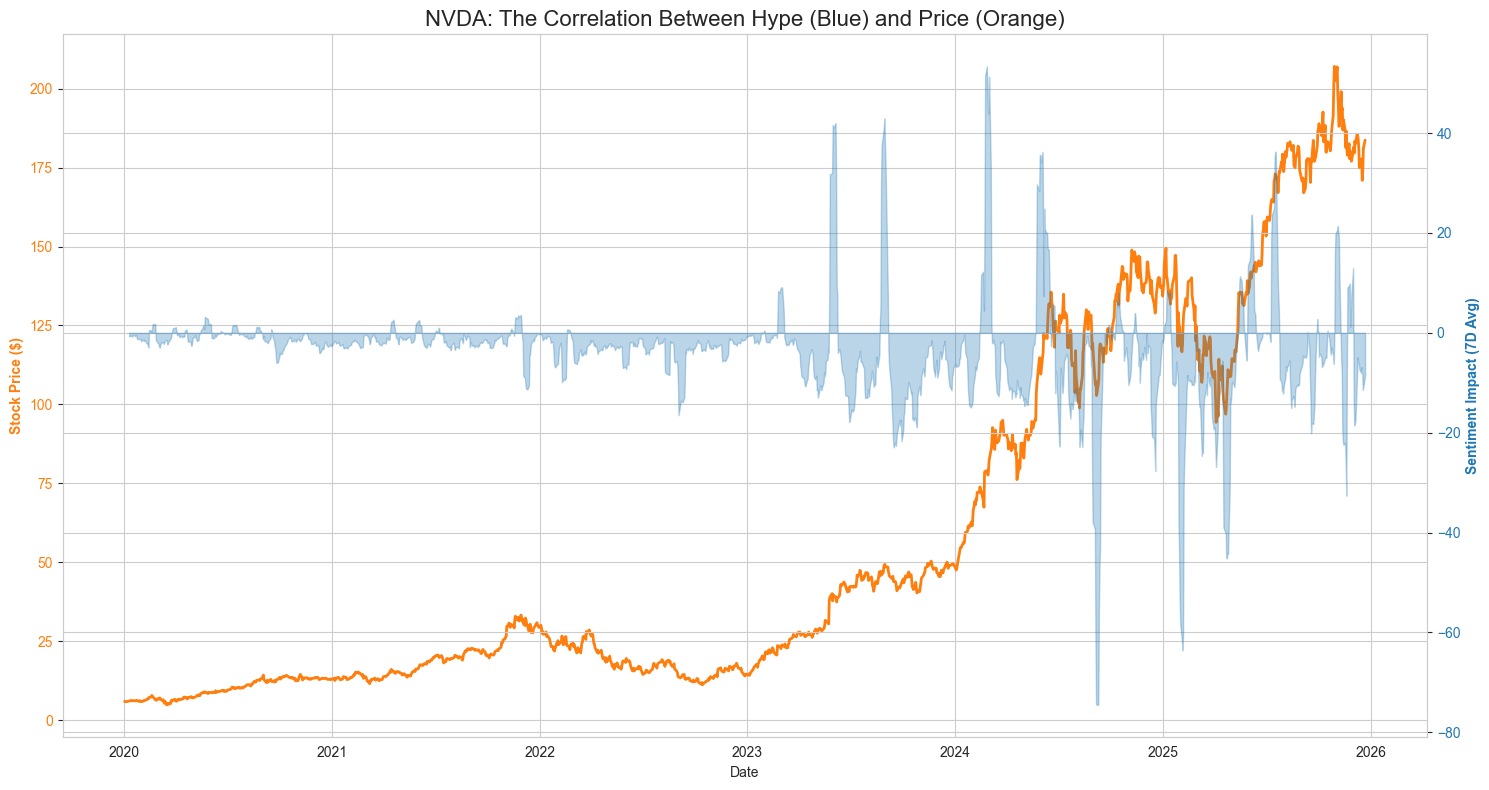

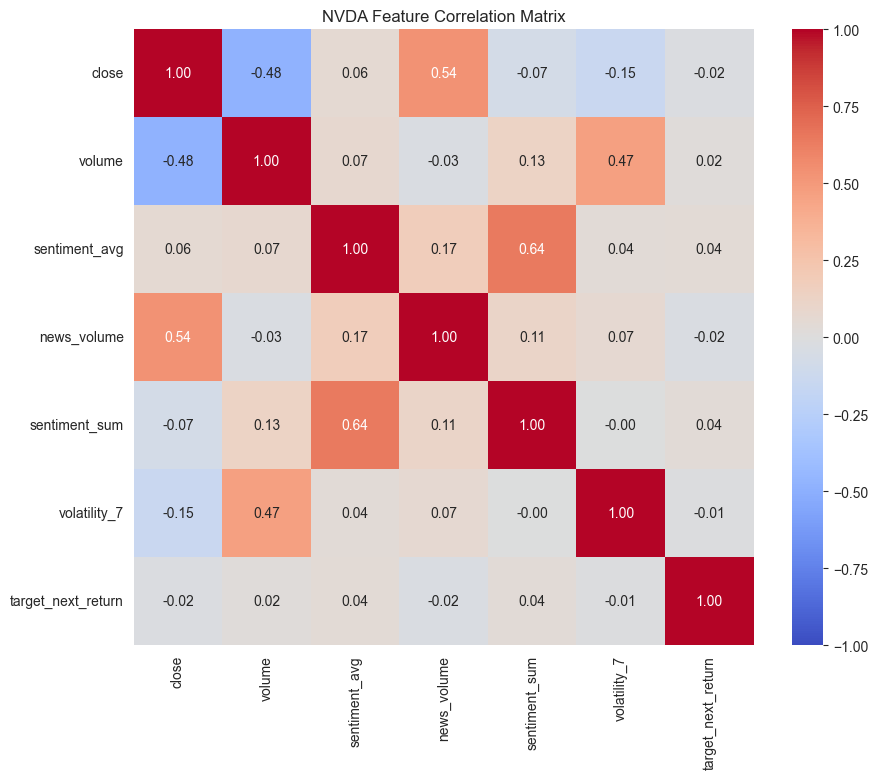

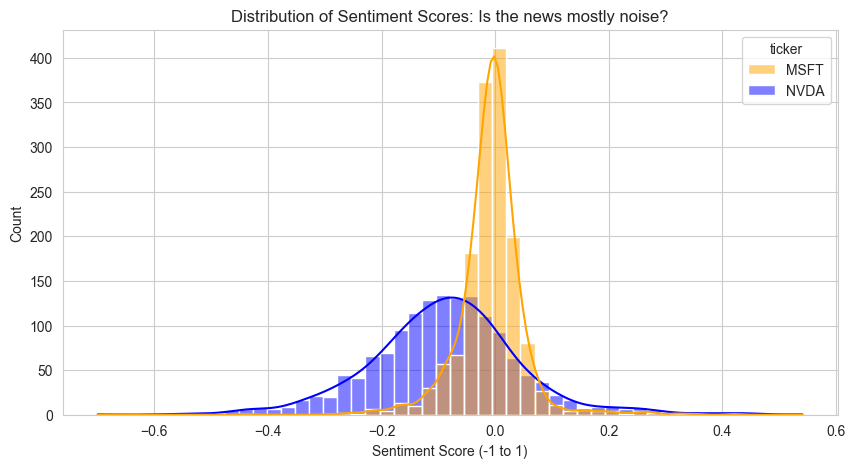

In [6]:
# Cell 6: Exploratory Data Analysis (EDA) for Director's Report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the Gold Data
# We use the full dataset (superset_dashboard_data.csv) to see all history
df = pd.read_csv(f"{GOLD_DIR}/superset_dashboard_data.csv")
df['date'] = pd.to_datetime(df['date'])

# 2. Feature Check & Creation (Robustness)
# If 'sentiment_sum' (Impact) isn't there yet, we calculate it: Avg * Volume
if 'sentiment_sum' not in df.columns:
    if 'news_volume' in df.columns:
        df['sentiment_sum'] = df['sentiment_avg'] * df['news_volume']
    else:
        df['sentiment_sum'] = df['sentiment_avg'] # Fallback

# 3. Define Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

def plot_hype_cycle(ticker):
    subset = df[df['ticker'] == ticker].sort_values('date')
    
    fig, ax1 = plt.subplots()
    
    # Plot Stock Price (Technical)
    color = 'tab:orange'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price ($)', color=color, fontweight='bold')
    ax1.plot(subset['date'], subset['close'], color=color, label='Stock Price', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Plot Sentiment Signal (Narrative)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    # We use a rolling mean on sentiment to show the "Trend" rather than noise
    sentiment_trend = subset['sentiment_sum'].rolling(window=7).mean()
    
    ax2.set_ylabel('Sentiment Impact (7D Avg)', color=color, fontweight='bold')
    ax2.fill_between(subset['date'], sentiment_trend, color=color, alpha=0.3, label='Sentiment Intensity')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f"{ticker}: The Correlation Between Hype (Blue) and Price (Orange)", fontsize=16)
    fig.tight_layout()
    plt.show()

def plot_correlation_heatmap(ticker):
    subset = df[df['ticker'] == ticker].copy()
    
    # Select impactful features
    cols = ['close', 'volume', 'sentiment_avg', 'news_volume', 'sentiment_sum', 'volatility_7', 'target_next_return']
    # Filter for existing columns
    cols = [c for c in cols if c in subset.columns]
    
    corr = subset[cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"{ticker} Feature Correlation Matrix")
    plt.show()

# --- EXECUTION ---
print("--- GENERATING DIRECTOR'S INSIGHTS ---")

# 1. The "Hype" Chart: Show this to prove News correlates with Price
# (Focus on Nvidia as the 'Hype' example)
if 'NVDA' in df['ticker'].unique():
    plot_hype_cycle('NVDA')

# 2. The Correlation Matrix: Prove 'Sentiment' is not just 'Price'
# (If Sentiment Sum has low correlation with Price but high with Volatility, that's a finding!)
if 'NVDA' in df['ticker'].unique():
    plot_correlation_heatmap('NVDA')

# 3. Sentiment Distribution: Prove the data isn't just "Neutral"
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='sentiment_avg', hue='ticker', kde=True, bins=50, palette=['orange', 'blue'])
plt.title("Distribution of Sentiment Scores: Is the news mostly noise?")
plt.xlabel("Sentiment Score (-1 to 1)")
plt.show()